# Description of the network and installed capacities before the optimization

In [2]:
import logging
import os

import pypsa
import yaml
import pandas as pd
import geopandas as gpd
import geoviews as gv
import hvplot.pandas
import numpy as np
import scipy as sp
import networkx as nx

# plotting stuff
import matplotlib.pyplot as plt

plt.style.use("bmh")
import seaborn as sns  ###
import cartopy.crs as ccrs

sns.set(style="darkgrid")

from scipy.sparse import csgraph
from itertools import product

from shapely.geometry import Point, LineString
import shapely, shapely.prepared, shapely.wkt

logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

## load network before optimization

In [3]:
input_solve_network = os.getcwd() + "/pypsa-earth/networks/GH-16-GADM-clustering/elec_s_16_ec_lcopt_Co2L-3H.nc" # change to a suitable path for you

n_input = pypsa.Network(input_solve_network)

INFO:pypsa.io:Imported network elec_s_16_ec_lcopt_Co2L-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Overview of the inputs and installed capacities

### Number of components by network type

In [4]:
n_input

PyPSA Network
Components:
 - Bus: 48
 - Carrier: 17
 - Generator: 46
 - GlobalConstraint: 1
 - Line: 22
 - Link: 64
 - Load: 16
 - StorageUnit: 2
 - Store: 32
Snapshots: 2920

### Overview of the characteristics of the network
Below we describe the main characteristics of the network are drawn:
- bus0: the first ending of the line
- bus1: the second ending of the line
- s_nom: the nominal capacity of the line
- capital_cost: the investment cost of the line
- s_nom_extendable: (True/False) binary value stating whether the line capacity can be upgraded

In [5]:
n_input.lines[["bus0", "bus1", "s_nom", "capital_cost", "s_nom_extendable"]].head(2)

,bus0,bus1,s_nom,capital_cost,s_nom_extendable
Line,,,,,
0,GH0 0,GH0 12,539.594448,7733.440423,True
1,GH0 0,GH0 15,539.594448,6096.384297,True


### Overview of the installed generation by carrier
Below we describe the main installed capacities (p_nom_opt), average specific capital cost (capital_cost) and average marginal cost (marginal_cost) by carrier and bus
- p_nom_opt: nominal installed capacity
- capital_cost: investment cost of the technology
- marginal_cost: marginal cost of the technology
- p_nom_extendable: (True/False) binary variable stating whether the capacity of the asset can be changed

In [6]:
gen_cap = n_input.generators.groupby(["bus", "carrier"])[
    ["p_nom_opt", "capital_cost", "marginal_cost", "p_nom_extendable"]
].agg(
    {
        "p_nom_opt": "sum",
        "capital_cost": "mean",
        "marginal_cost": "mean",
        "p_nom_extendable": "sum",
    }
)
gen_cap.head(5)

p_nom_opt   capital_cost  marginal_cost  p_nom_extendable
bus   carrier                                                              
GH0 0 onwind            0.0  109295.569252          0.015                 1
      solar             0.0   50855.958267          0.010                 1
GH0 1 offwind-ac        0.0  191414.330263          0.015                 1
      offwind-dc        0.0  236763.877190          0.015                 1
      onwind            0.0  109295.569252          0.015                 1

### Average specific energy production by node and carrier
In this picture, we detail the specific energy production by bus and carrier; the output is a panda Series
In the first column (first index) the bus name is shown; in the second column (second index), the carrier is specified and finally the energy quantity is detailed in the last column

In [7]:
n_input.generators_t.p_max_pu.sum().rename("en_pu").head(15)

Generator
GH0 0 onwind         196.973792
GH0 0 solar          442.256643
GH0 1 offwind-ac       0.000000
GH0 1 offwind-dc     324.260689
GH0 1 onwind         171.961861
GH0 1 solar          418.965146
GH0 10 onwind        234.599730
GH0 10 solar         457.100006
GH0 11 offwind-ac      0.000000
GH0 11 offwind-dc    331.721077
GH0 11 onwind        100.564947
GH0 11 solar         368.574269
GH0 12 onwind        262.035969
GH0 12 solar         459.629727
GH0 13 onwind         67.659342
Name: en_pu, dtype: float64

### Plot of the demand by bus
In this cells, the total demand by bus is created and denoted as `load_serie`, then it is plotted to show the location of the demand.
In the plot, the size of the dot denotes the total demand and the size of the lines in the network denotes the total network capacity between the nodes.

In [8]:
# Creation of the load series by bus
load_serie = n_input.loads_t.p_set.sum().rename("load").rename_axis("bus")

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


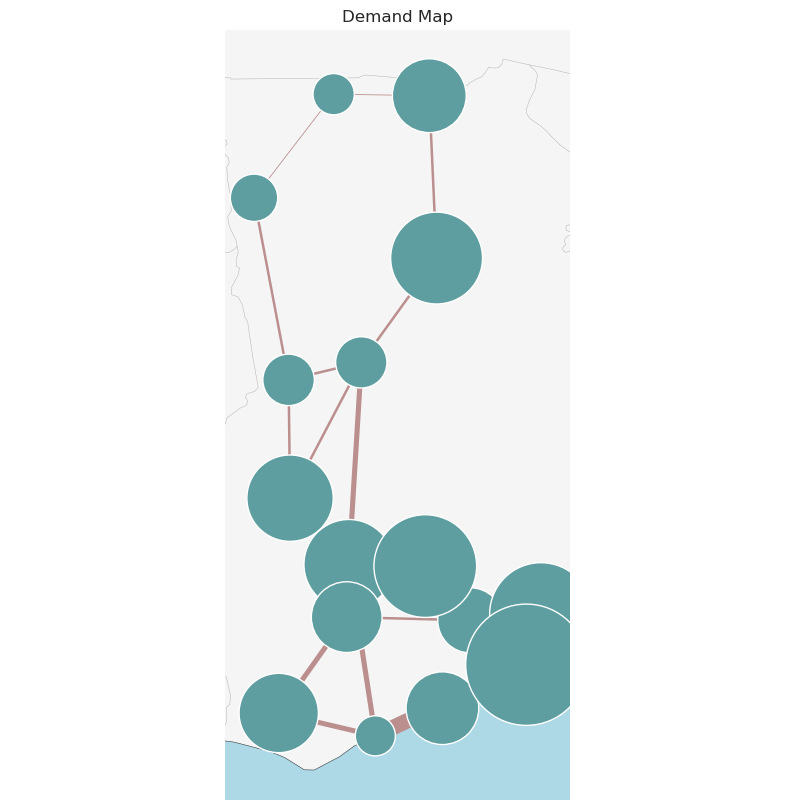

In [9]:
# plot the load serie

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },  # PlateCarree(default), Mercator, Orthographic
)

n_input.plot(
    margin=0.1,
    ax=None,
    geomap=True,  #'10m' leads to a beautiful high resolution map
    projection=None,
    bus_colors="cadetblue",
    bus_alpha=1,
    bus_sizes=load_serie
    * 0.0000003,  # n.loads_t.p_set.sum().rename("load").rename_axis("bus")*.0000003,
    bus_cmap=None,
    line_colors="rosybrown",
    link_colors="darkseagreen",  # loading
    transformer_colors="orange",
    line_widths=n_input.lines.s_nom / 3e2,
    link_widths=1.5,
    transformer_widths=1.5,
    line_cmap=None,
    link_cmap=None,  # plt.cm.virdis (colordmap for line loading)
    transformer_cmap=None,
    flow=None,
    branch_components=None,
    layouter=None,
    title="Demand Map",
    boundaries=None,
    geometry=False,
    jitter=None,
    color_geomap=True,
)  # None or True

ax.axis("off");

In [10]:
n_input.generators

,carrier,bus,p_nom_min,p_nom,p_nom_extendable,efficiency,marginal_cost,capital_cost,p_nom_max,weight,control,p_max_pu,type,p_nom_mod,p_min_pu,p_set,q_set,sign,marginal_cost_quadratic,build_year,lifetime,committable,start_up_cost,shut_down_cost,stand_by_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GH0 0 onwind,onwind,GH0 0,0.000000,0.000000,True,1.000,0.015000,109295.569252,1.128491e+05,6936.813385,Slack,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
GH0 0 solar,solar,GH0 0,56.221260,56.221260,True,1.000,0.010000,50855.958267,1.516857e+05,22970.357469,,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
GH0 1 offwind-ac,offwind-ac,GH0 1,0.000000,0.000000,True,1.000,0.015000,191414.330263,0.000000e+00,0.000000,,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
GH0 1 offwind-dc,offwind-dc,GH0 1,0.000000,0.000000,True,1.000,0.015000,236763.877190,6.423719e+04,7152.149733,,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
GH0 1 onwind,onwind,GH0 1,0.000000,0.000000,True,1.000,0.015000,109295.569252,7.097459e+03,346.964057,,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
GH0 1 solar,solar,GH0 1,1.900903,1.900903,True,1.000,0.010000,50855.958267,6.022578e+03,863.013466,,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
GH0 10 onwind,onwind,GH0 10,0.000000,0.000000,True,1.000,0.015000,109295.569252,4.162557e+04,3237.142032,,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
GH0 10 solar,solar,GH0 10,25.825419,25.825419,True,1.000,0.010000,50855.958267,6.742488e+04,10554.453728,,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
GH0 11 offwind-ac,offwind-ac,GH0 11,0.000000,0.000000,True,1.000,0.015000,191414.330263,0.000000e+00,0.000000,,1.0,,0.0,0.0,0.0,0.0,1.0,0.0,0,inf,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
